In [1]:
# Install required packages
!pip install --upgrade --quiet natural-pdf[all]

print('✓ Packages installed!')

zsh:1: no matches found: natural-pdf[all]
✓ Packages installed!


**Slides:** [slides.pdf](./slides.pdf)

In [2]:
from natural_pdf import PDF

pdf = PDF("https://github.com/jsoma/ire25-natural-pdf/raw/refs/heads/main/Atlanta_Public_Schools_GA_sample.pdf")
pdf

<PDF source='https://github.com/jsoma/ire25-natural-pdf/raw/refs/heads/main/Atlanta_Public_Schools_GA_sample.pdf' pages=5>

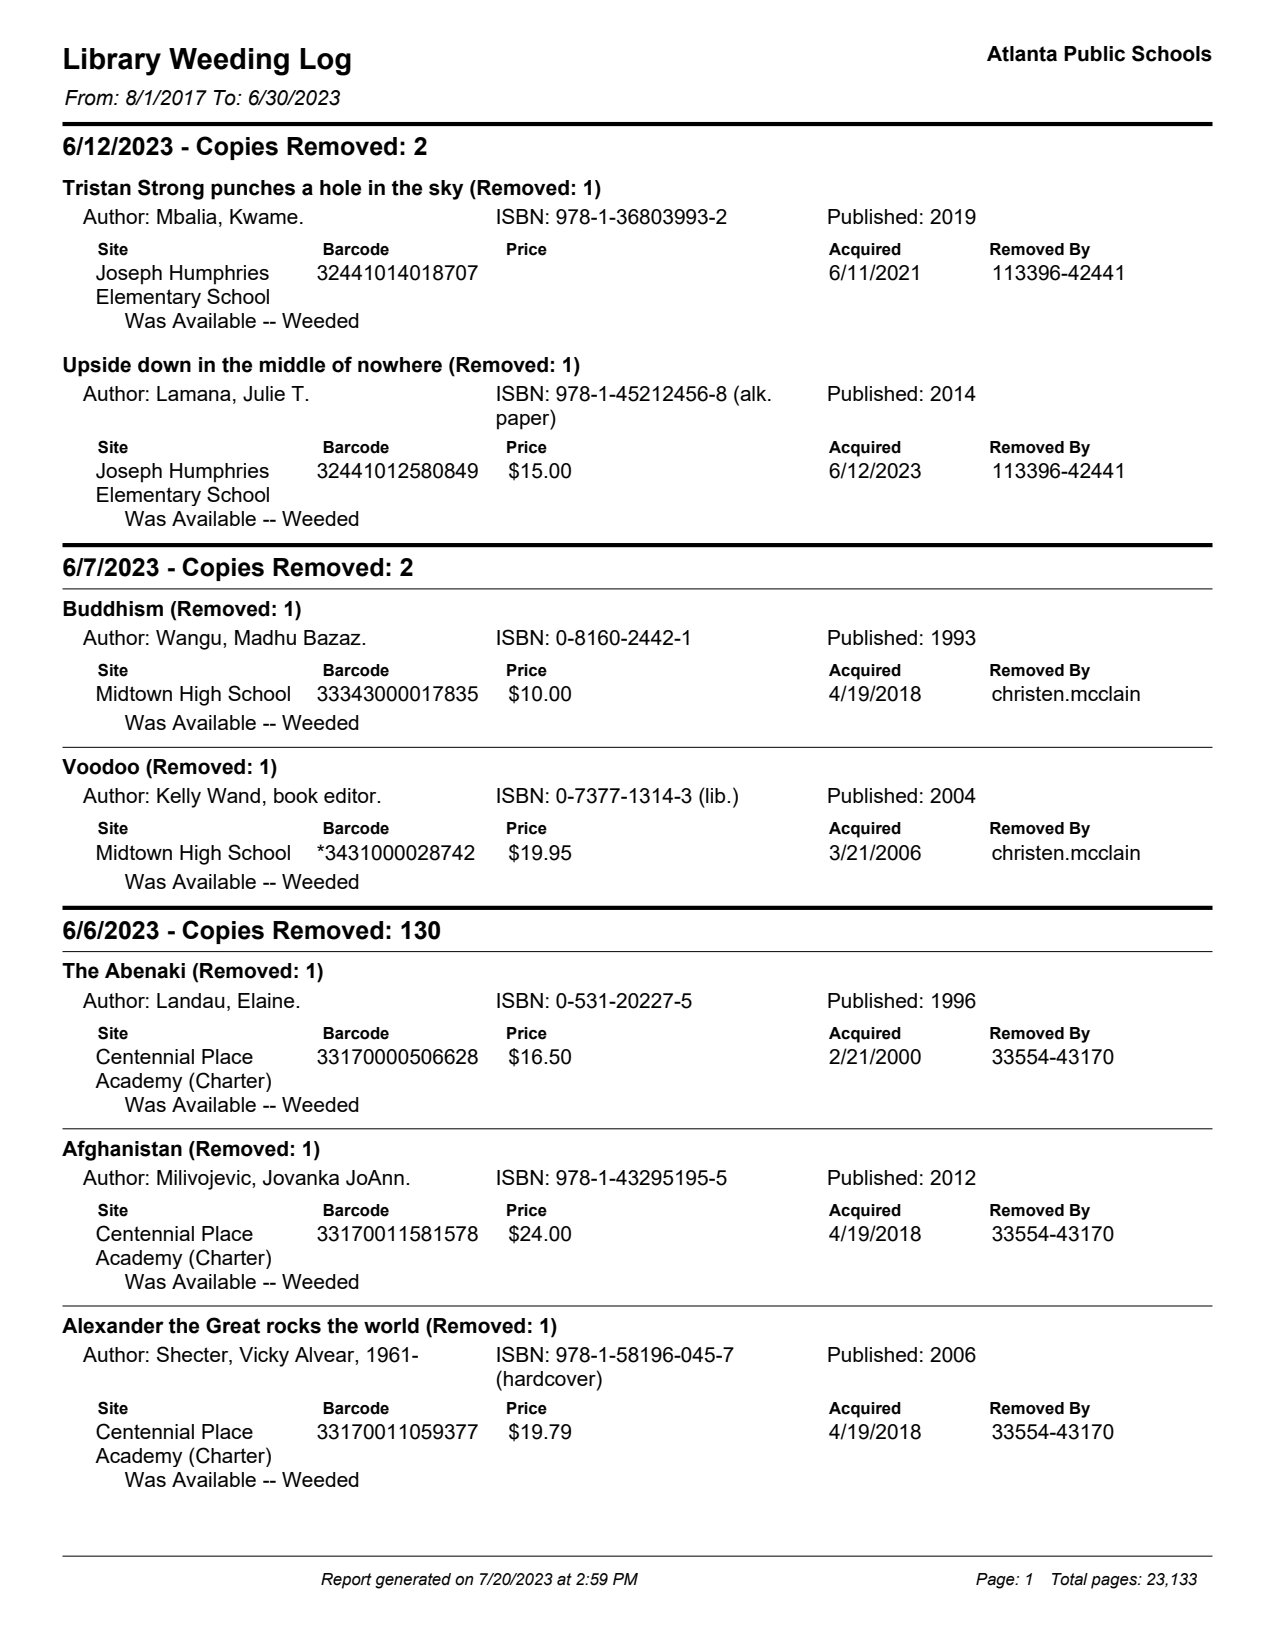

In [3]:
page = pdf.pages[0]
page.show()

We'll add two **exclusion zones** because we aren't interested in the top and bottom of the pages.

In [ ]:
pdf.add_exclusion(lambda page: page.find('line[width>=2]').above())
pdf.add_exclusion(lambda page: page.find_all('line')[-1].below())

In [ ]:
page.find_all('text').inspect()

In [ ]:
titles = page.find_all('text[font_variant=AAAAAB][size=10]')
titles.show()

In [ ]:
books = titles.below(until='text[font_variant=AAAAAB][size=10]',
                     include_endpoint=False,
                     include_source=True)
books.show()

In [ ]:
books.find('text:contains(Site)').below().clip(books).find_all('text[x0<47][size=10]')

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'author': books.find('text:contains(Author)').extract_each_text(),
    'isbn': books.find('text:contains(ISBN)').extract_each_text(),
    'published': books.find('text:contains(Published)').extract_each_text(),
    'site': books.find('text:contains(Site)').below().clip(books).apply(lambda area: area.find_all('text[x0<47][size=10]').extract_text()),
    'barcode': books.find('text:contains(Barcode)').below(width='element', height=12).expand(right=50).extract_each_text(),
    'price': books.find('text:contains(Price)').below(width='element', height=12).expand(right=50).extract_each_text(),
    'acquired': books.find('text:contains(Acquired)').below(width='element', height=12).expand(right=10).extract_each_text(),
    'removed_by': books.find('text:contains(Removed By)').below(width='element', height=12).expand(right=40).extract_each_text(),
    'date': books.above().find('text[size>10]').extract_each_text()
})
df

In [ ]:
#page.find_all('text[size>10]').show()
sections = page.get_sections('text[size>10]')

sections[0].show()